## Machine learning in linear regression

#### BUSINESS UNDERSTANDING

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
insurance_details=pd.read_csv(filepath_or_buffer="insurance data.csv")
insurance_details

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


#### DATA UNDERSTANDING 

In [3]:
insurance_details.shape

(1340, 7)

In [4]:
insurance_details.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
insurance_details.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [6]:
insurance_details.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,3.806307
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,10.636903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,0.400000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.069500
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,3.781500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


#### DATA PREPARATION

In [7]:
insurance_details.dropna(inplace=True)
insurance_details

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [8]:
x=insurance_details.drop(labels=["CASENUM","ATTORNEY"],axis=1)
x

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [9]:
y=insurance_details[["ATTORNEY"]]
y

,ATTORNEY
0,0
1,1
2,1
3,0
4,1
...,...
1334,1
1336,0
1337,1
1338,0


In [10]:
x.shape

(1096, 5)

In [11]:
x.isna().sum()

CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [12]:
y.shape

(1096, 1)

In [13]:
y.isna().sum()

ATTORNEY    0
dtype: int64

#### MODEL BUILDING

In [14]:
from sklearn.linear_model import LogisticRegression
logistic_model =LogisticRegression()

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,shuffle=True, random_state=125,stratify=y)
x_train,x_test,y_train,y_test

(      CLMSEX  CLMINSUR  SEATBELT  CLMAGE    LOSS
 153      0.0       1.0       0.0    66.0   0.507
 1072     1.0       1.0       0.0    33.0   3.030
 98       0.0       1.0       0.0    16.0   8.698
 1292     0.0       1.0       0.0    10.0   0.964
 589      1.0       1.0       0.0    30.0   0.830
 ...      ...       ...       ...     ...     ...
 1081     1.0       1.0       0.0    77.0   1.000
 1286     1.0       1.0       1.0    44.0  55.709
 1107     0.0       1.0       0.0    50.0   3.786
 457      1.0       1.0       0.0    48.0   0.116
 317      1.0       1.0       0.0     6.0   0.040
 
 [876 rows x 5 columns],
       CLMSEX  CLMINSUR  SEATBELT  CLMAGE    LOSS
 799      1.0       1.0       0.0    17.0   0.000
 1176     0.0       1.0       0.0    56.0  15.001
 707      1.0       1.0       0.0    45.0   0.900
 1058     1.0       1.0       0.0    19.0   1.985
 171      1.0       1.0       0.0    41.0   4.840
 ...      ...       ...       ...     ...     ...
 507      0.0       1.0

#### MODEL TRAINING

In [16]:
logistic_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### MODEL TESTING 

##### TRAINING DATA:

In [17]:
y_pred_train=logistic_model.predict(x_train)
print(y_pred_train)

[1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 1 1
 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1
 0 0 1 1 0 1 1 1 0 0 1 0 0 1 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 0 1 1 0 0
 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 1 1 1 1 0 0 1 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1
 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 1 1 1 1 0 1 0 0 0 0 0 1 0 0 1
 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 1 1 1
 0 0 0 0 0 1 0 1 1 1 0 1 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 1 0 1 0 0 0 0 1 0
 1 0 1 1 1 0 1 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 0 0 0 1 0 0 1 0 0 1 1 1
 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1
 0 0 1 0 1 1 0 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 0 1 0 0 1 0 1 1 1 0 0 0 1 1 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 0 0 0 0 1 0
 0 1 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0
 1 1 1 0 1 0 1 0 1 0 1 0 

##### TESTING DATA:

In [18]:
y_pred_test=logistic_model.predict(x_test)
print(y_pred_test)

[1 0 1 1 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1
 1 0 1 0 0 0 1 0 1 1 1 0 1 0 1 0 1 1 0 0 1 1 0 1 0 1 1 1 0 0 1 1 0 1 1 0 0
 0 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 1 0 1 1 1 1 1 0 0 0 0
 1 0 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 1 1
 0 1 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 0 1 1 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


#### MODEL EVALUATION

In [19]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,f1_score,roc_curve,roc_auc_score
print(classification_report(y_true=y_train,y_pred=y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.67      0.71       462
           1       0.67      0.75      0.71       414

    accuracy                           0.71       876
   macro avg       0.71      0.71      0.71       876
weighted avg       0.71      0.71      0.71       876



In [20]:
accuracy_score(y_true=y_train, y_pred=y_pred_train)

0.7077625570776256

In [21]:
print(confusion_matrix(y_true=y_train, y_pred=y_pred_train))

[[308 154]
 [102 312]]


In [22]:
f1_score(y_true=y_train, y_pred=y_pred_train)

0.7090909090909091

In [23]:
fpr,tpr,thresholds=roc_curve(y_train,logistic_model.predict_proba(x_train)[:,1])
fpr,tpr,thresholds

(array([0.        , 0.        , 0.        , 0.0021645 , 0.0021645 ,
        0.00649351, 0.00649351, 0.00865801, 0.00865801, 0.01082251,
        0.01082251, 0.01298701, 0.01298701, 0.01515152, 0.01515152,
        0.02164502, 0.02164502, 0.02380952, 0.02380952, 0.02813853,
        0.02813853, 0.03030303, 0.03030303, 0.03246753, 0.03246753,
        0.03463203, 0.03463203, 0.03679654, 0.03679654, 0.03896104,
        0.03896104, 0.04112554, 0.04112554, 0.04329004, 0.04545455,
        0.04545455, 0.04761905, 0.04761905, 0.04978355, 0.04978355,
        0.05194805, 0.05194805, 0.05411255, 0.05844156, 0.05844156,
        0.06060606, 0.06060606, 0.06277056, 0.06277056, 0.06493506,
        0.06493506, 0.06709957, 0.06709957, 0.07359307, 0.07359307,
        0.07575758, 0.07575758, 0.08441558, 0.08441558, 0.08658009,
        0.08658009, 0.08874459, 0.08874459, 0.09090909, 0.09090909,
        0.0952381 , 0.0952381 , 0.0995671 , 0.0995671 , 0.1017316 ,
        0.1017316 , 0.1038961 , 0.1038961 , 0.10

0.7101449275362319


Text(0, 0.5, 'True Positive rate')

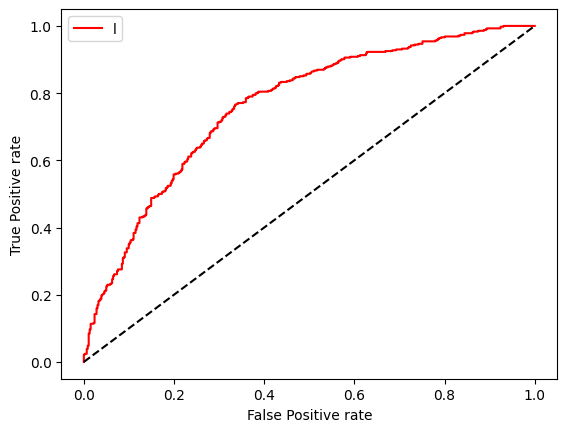

In [32]:
auc=roc_auc_score(y_true=y_train, y_score=y_pred_train)
print(auc)
plt.plot(fpr,tpr,color="red",label='logistic_model,{AUC=%0.2f}' % auc)
plt.legend("lower right")
plt.plot([0,1],[0,1],color="black",linestyle="--")
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")

0.7055702917771883


Text(0, 0.5, 'True Positive rate')

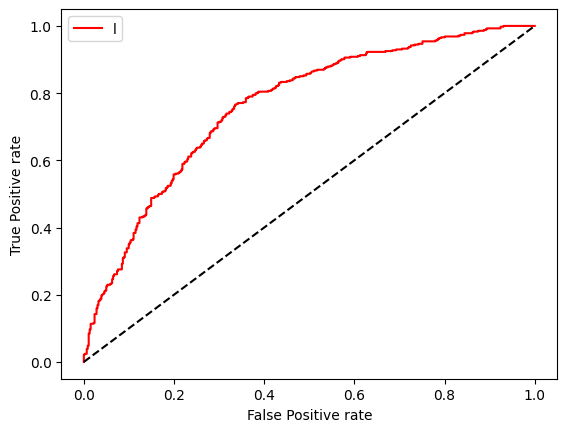

In [33]:
auc=roc_auc_score(y_true=y_test, y_score=y_pred_test)
print(auc)
plt.plot(fpr,tpr,color="red",label='logistic_model,{AUC=%0.2f}' % auc)
plt.legend("lower right")
plt.plot([0,1],[0,1],color="black",linestyle="--")
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")

### THE END

=========================================================================================================================================